# Multi-Layer Perceptron (MLP)
author : [Maxime Devanne](https://www.maxime-devanne.com)

## Import librairies

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

## Classification

### Pokemon Stats Dataset

#### Downloading the dataset

In [ ]:
!wget https://maxime-devanne.com/datasets/Pokemon_stats/pokemon-stats-data.csv

--2026-02-09 08:11:43--  https://maxime-devanne.com/datasets/Pokemon_stats/pokemon-stats-data.csv
Resolving maxime-devanne.com (maxime-devanne.com)... 213.186.33.4, 2001:41d0:1:1b00:213:186:33:4
Connecting to maxime-devanne.com (maxime-devanne.com)|213.186.33.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22598 (22K) [text/csv]
Saving to: ‘pokemon-stats-data.csv’

pokemon-stats-data. 100%[===================>]  22.07K   137KB/s    in 0.2s    

2026-02-09 08:11:44 (137 KB/s) - ‘pokemon-stats-data.csv’ saved [22598/22598]



#### Reading the dataset

In [ ]:
df = pd.read_csv("pokemon-stats-data.csv")
df.head()

,name,weight_kg,speed,sp_attack,sp_defense,type
0,Bulbasaur,6.9,45,65,65,grass
1,Ivysaur,13.0,60,80,80,grass
2,Venusaur,100.0,80,122,120,grass
3,Charmander,8.5,65,60,50,fire
4,Charmeleon,19.0,80,80,65,fire


#### Dataset preparation

##### Cleaning

In [ ]:
df = df.dropna()

##### Reduction into 3 classes
We will use a reduced version with only 3 classes :
- fairy
- ground
- flying

In [ ]:
df_types = df[(df["type"] !="test")]
types = df_types["type"].unique()

In [ ]:
df = df[(df["type"] == "fairy") | (df["type"] == "ground") | (df["type"] == "flying")]

##### Extraction of input data

We will use 4 attributes:
- weight
- speed
- sp_attack
- sp_defense

In [ ]:
X = np.asarray(df[["weight_kg","speed","sp_attack","sp_defense"]], dtype=np.float32)
print(X.shape)

(48, 4)


##### Preparing output data (class labels)
In a multi-class classification, we need to have a one-hot vector representation of labels.

In [ ]:
y = np.asarray(df["type"])

le = LabelEncoder()
y = le.fit_transform(y)

ohe = OneHotEncoder()
y = ohe.fit_transform(y.reshape(-1,1)).toarray()

print(y.shape)
print(y[0])

(48, 3)
[1. 0. 0.]


##### train-test split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=33/100, random_state=42)

##### Normalization

In [ ]:
scaler = MinMaxScaler().fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

### Building a MLP

#### Input layer

In [ ]:
input_shape = x_train.shape[1:]
input_layer = tf.keras.layers.Input(input_shape)

#### Hidden layer
Includes 16 neurons with a `sigmoid` activation

In [ ]:
# the hidden layer is connected to the input layer
hidden_layer = tf.keras.layers.Dense(units=16, activation='sigmoid')(input_layer)

#### Output layer
Includes as many neurones as the number of classes, and uses a `softmax` activation


In [ ]:
nb_classes = y_train.shape[1]
output_layer = tf.keras.layers.Dense(units=nb_classes,activation='softmax')(hidden_layer)

#### Creating the MLP model

In [ ]:
model_mlp = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

#### Visualizing the model

In [ ]:
# textual information
model_mlp.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

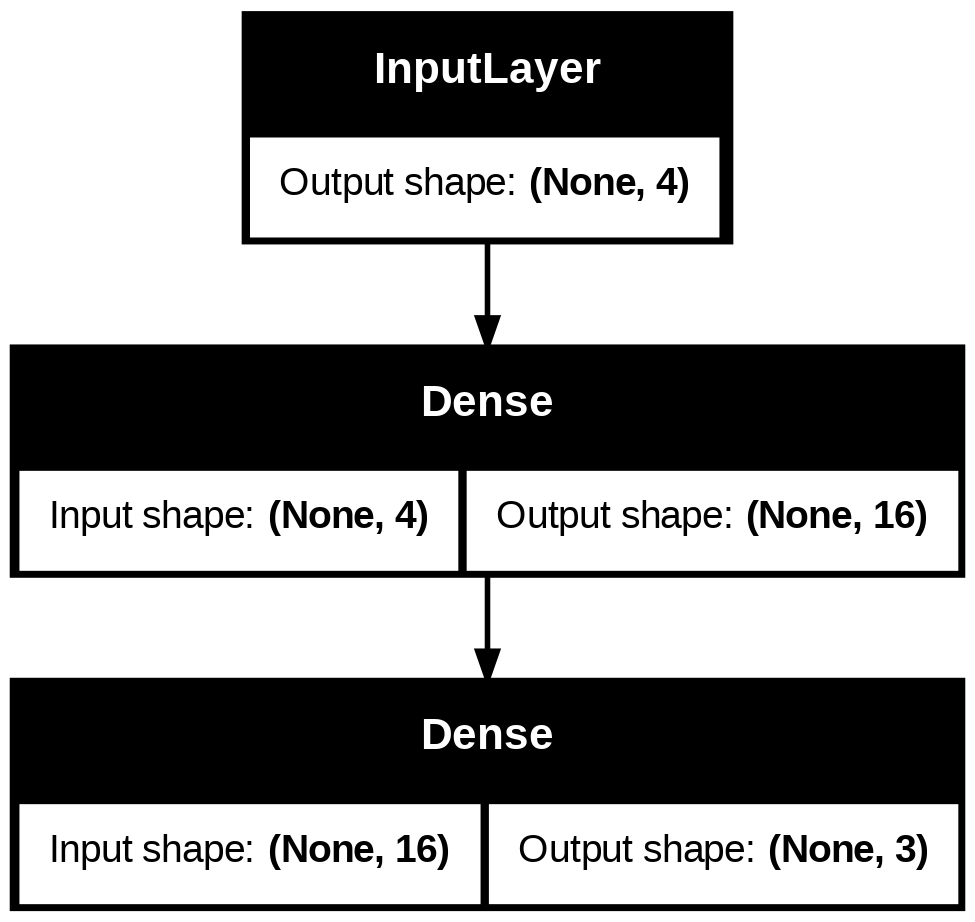

In [ ]:
# connected graph
tf.keras.utils.plot_model(model_mlp, show_shapes=True)

#### Compilation of the model
We have to specify :
- the optimization algorithm with the learning rate
- the cost function
- an additional metric (optionnal)

In [ ]:
# Optimizer : Adam
learning_rate = 0.001
optimizer_algo = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# Cost function : Categorical Cross-Entropy
cost_function = tf.keras.losses.categorical_crossentropy

# Model compilation with the 'accuracy' as additional metric
model_mlp.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])

### Training the MLP

In [ ]:
nb_epochs = 1000
mini_batch_size = 32
percentage_of_train_as_validation = 0.2
model_checkpoint = tf.keras.callbacks.ModelCheckpoint('best-model.keras', monitor='val_loss', save_best_only=True)

#### Running the training
It is possible to put the hyper-parameter `verbose` to `False` to not see results at each epoch



**Be patient :)**

In [ ]:
history_mlp = model_mlp.fit(x_train,y_train,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=True,
                    validation_split=percentage_of_train_as_validation,
                    callbacks=[model_checkpoint])

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4400 - loss: 1.1481 - val_accuracy: 0.4286 - val_loss: 1.1461
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.4400 - loss: 1.1418 - val_accuracy: 0.4286 - val_loss: 1.1416
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.4400 - loss: 1.1356 - val_accuracy: 0.4286 - val_loss: 1.1373
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.4400 - loss: 1.1295 - val_accuracy: 0.4286 - val_loss: 1.1330
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4400 - loss: 1.1234 - val_accuracy: 0.4286 - val_loss: 1.1288
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4400 - loss: 1.1174 - val_accuracy: 0.4286 - val_loss: 1.1247
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4400 - loss: 1.1116 - val_accuracy: 0.4286 - val_loss: 1.1207
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.4400 - loss: 1.1058 - val_accuracy: 0.4286 - va

You now have a 'best-model.keras' saved in the environment.

### Plot the loss variation

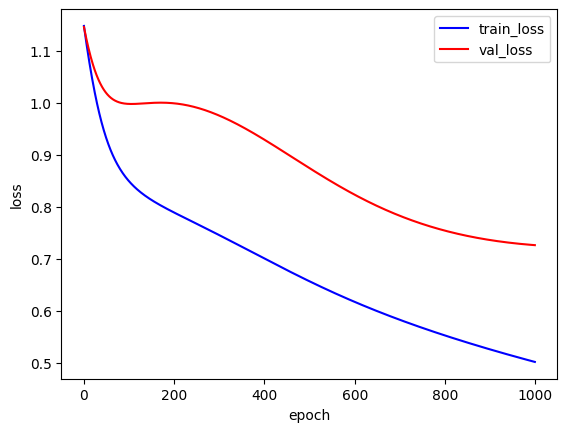

In [ ]:
history_dict = history_mlp.history
loss_train_epochs = history_dict['loss']
loss_val_epochs = history_dict['val_loss']

plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss')
plt.plot(loss_val_epochs,color='red',label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss.pdf')
plt.show()
plt.close()

### Choose the best model

In [ ]:
model = tf.keras.models.load_model('best-model.keras')

### Evaluate its performance on the test set

In [ ]:
loss,acc = model.evaluate(x_test,y_test)

print("Accuracy on the test set:",acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step - accuracy: 0.7500 - loss: 0.5451
Accuracy on the test set: 0.75


### **Exercises**

#### Try to improve the model by adding a second hidden layer with 16 neurons. Compare the results.




In [ ]:
input_shape = x_train.shape[1:]
input_layer = tf.keras.layers.Input(input_shape)
hidden_layer = tf.keras.layers.Dense(units=16, activation='sigmoid')(input_layer)
hidden_layer2 = tf.keras.layers.Dense(units=16, activation='sigmoid')(hidden_layer)
output_layer = tf.keras.layers.Dense(units=nb_classes,activation='softmax')(hidden_layer2)
# create a new model
model_mlp2 = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
model_mlp2.summary()

learning_rate = 0.001
optimizer_algo = tf.keras.optimizers.Adam(learning_rate=learning_rate)
cost_function = tf.keras.losses.categorical_crossentropy

model_mlp2.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403 (1.57 KB)

 Trainable params: 403 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

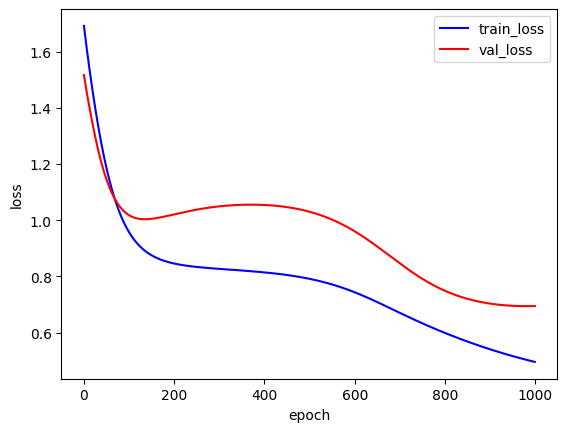

In [ ]:
# create a new checkpoint if we want to save the model with a new name
nb_epochs = 1000
mini_batch_size = 32
percentage_of_train_as_validation = 0.2
model_checkpoint = tf.keras.callbacks.ModelCheckpoint('best-model2.keras', monitor='val_loss', save_best_only=True)

history_mlp2 = model_mlp2.fit(x_train,y_train,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=False,
                    validation_split=percentage_of_train_as_validation,
                    callbacks=[model_checkpoint])

history_dict = history_mlp2.history
loss_train_epochs = history_dict['loss']
loss_val_epochs = history_dict['val_loss']

plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss')
plt.plot(loss_val_epochs,color='red',label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss.pdf')
plt.show()
plt.close()

In [ ]:
model2 = tf.keras.models.load_model('best-model2.keras')
loss,acc = model2.evaluate(x_test,y_test)
print("Accuracy on the test set:",acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step - accuracy: 0.7500 - loss: 0.5582
Accuracy on the test set: 0.75


#### Try to remove non-linear activation in hidden layer and put them as linear (activation='linear'). Compare the results

In [ ]:
input_shape = x_train.shape[1:]
input_layer = tf.keras.layers.Input(input_shape)
hidden_layer = tf.keras.layers.Dense(units=16, activation='linear')(input_layer)
hidden_layer2 = tf.keras.layers.Dense(units=16, activation='linear')(hidden_layer)
output_layer = tf.keras.layers.Dense(units=nb_classes,activation='softmax')(hidden_layer2)
# create a new model
model_mlp3 = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
model_mlp3.summary()

learning_rate = 0.001
optimizer_algo = tf.keras.optimizers.Adam(learning_rate=learning_rate)
cost_function = tf.keras.losses.categorical_crossentropy

model_mlp3.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403 (1.57 KB)

 Trainable params: 403 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

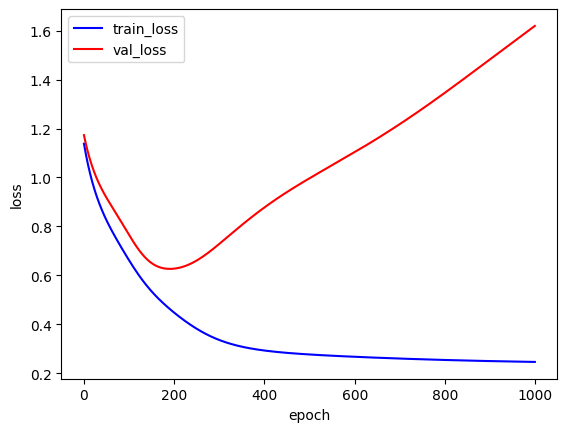

In [ ]:
# create a new checkpoint if we want to save the model with a new name
nb_epochs = 1000
mini_batch_size = 32
percentage_of_train_as_validation = 0.2
model_checkpoint = tf.keras.callbacks.ModelCheckpoint('best-model3.keras', monitor='val_loss', save_best_only=True)

history_mlp3 = model_mlp3.fit(x_train,y_train,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=False,
                    validation_split=percentage_of_train_as_validation,
                    callbacks=[model_checkpoint])

history_dict = history_mlp3.history
loss_train_epochs = history_dict['loss']
loss_val_epochs = history_dict['val_loss']

plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss')
plt.plot(loss_val_epochs,color='red',label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss.pdf')
plt.show()
plt.close()

In [ ]:
model3 = tf.keras.models.load_model('best-model3.keras')
loss,acc = model3.evaluate(x_test,y_test)
print("Accuracy on the test set:",acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.8125 - loss: 0.5548
Accuracy on the test set: 0.8125


## Regression

### Synthetic dataset

We will create a synthetic dataset representing a non-linear function to be estimated by a MLP.

In [ ]:
# Create data with equation y=0.1*x*x*sin(x)
x_data = np.linspace(-10, 10, num=1000)
y_data = 0.1*x_data*x_data*np.sin(x_data) + 0.5*np.random.normal(size=1000)

Plot the dataset

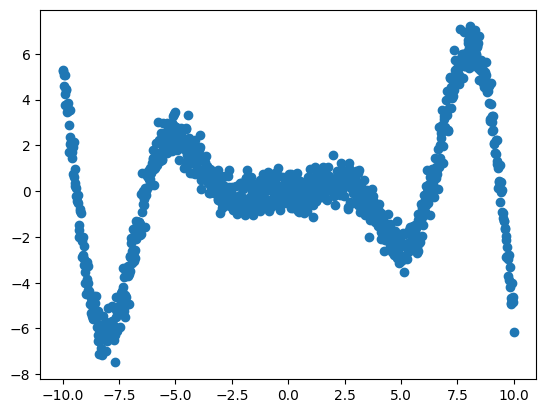

In [ ]:
plt.scatter(x_data,y_data)

Add a dimension in the dataset to fit Keras models.

In [ ]:
x_data = np.expand_dims(x_data,axis=1)
y_data = np.expand_dims(y_data,axis=1)

### Building the non-linear regression model

It contains a hidden layer of 64 neurons.

In [ ]:
tf.random.set_seed(42)

input_layer = tf.keras.Input(shape=(x_data.shape[1],))
hidden_layer = tf.keras.layers.Dense(units=64,activation='relu')(input_layer)
output_layer = tf.keras.layers.Dense(units=1, activation='linear')(hidden_layer)

multi_layer_model_regression = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
multi_layer_model_regression.summary()
multi_layer_model_regression.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mse')

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 1)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 64)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

### Training the model

In [ ]:
nb_epochs = 1000
history = multi_layer_model_regression.fit(x_data,y_data,epochs=nb_epochs,verbose=True)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.2733
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.8617
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6808
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6019
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5454
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4987
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4456
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3887
Epoch 9/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3396
Epoch 10/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2936
Epoch 11/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2555
Epoch 12/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2222
Epoch 13/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1933
Epoch 14/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1657
Epoch 15/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - l

Plot the loss curve

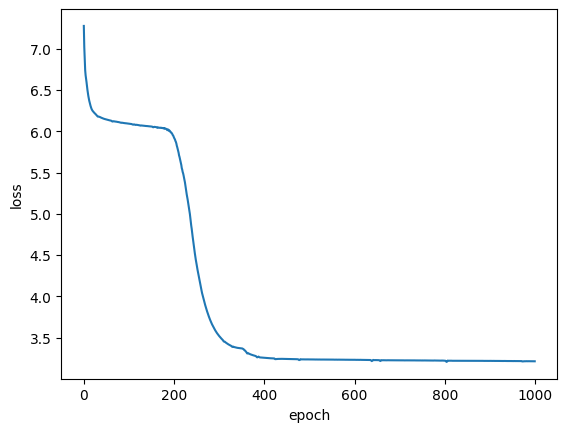

In [ ]:
history_dict = history.history
loss_epochs = history_dict['loss']

plt.figure()
plt.plot(loss_epochs)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()
plt.close()

### Evaluation of the model

In [ ]:
loss = multi_layer_model_regression.evaluate(x_data,y_data,verbose=False)

print("The loss on the test set is:",loss)

The loss on the test set is: 3.1364569664001465


Plot the predicted decision

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


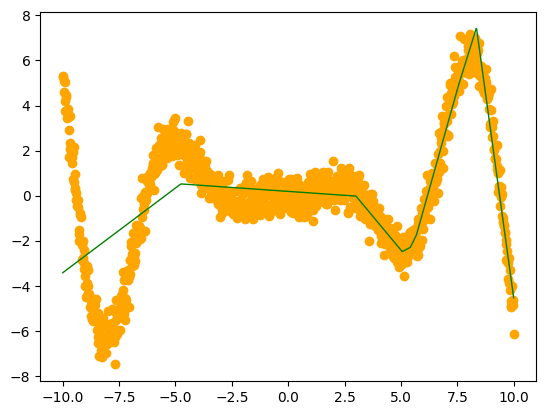

In [ ]:
# Compute the output
y_predicted = multi_layer_model_regression.predict(x_data)

# Display the result
plt.scatter(x_data[::1], y_data[::1], color='orange')
plt.plot(x_data, y_predicted, 'g', linewidth=1)

### **Exercise**

#### Add a second hidden layer with 64 neurons and compare the predictions

In [ ]:
input_layer = tf.keras.Input(shape=(x_data.shape[1],))
hidden_layer = tf.keras.layers.Dense(units=64,activation='relu')(input_layer)
hidden_layer2 = tf.keras.layers.Dense(units=64,activation='relu')(hidden_layer)
output_layer = tf.keras.layers.Dense(units=1, activation='linear')(hidden_layer2)

multi_layer_model_regression2 = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
multi_layer_model_regression2.summary()
multi_layer_model_regression2.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mse')

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 1)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 64)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
nb_epochs = 1000
history = multi_layer_model_regression2.fit(x_data,y_data,epochs=nb_epochs,verbose=False)

The loss on the test set is: 0.3073287308216095
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


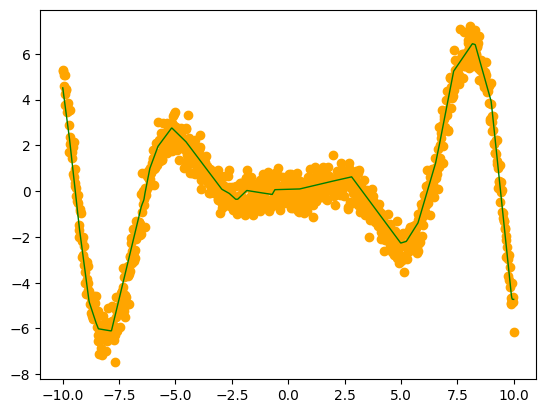

In [ ]:
loss = multi_layer_model_regression2.evaluate(x_data,y_data,verbose=False)
print("The loss on the test set is:",loss)

# Compute the output
y_predicted = multi_layer_model_regression2.predict(x_data)

# Display the result
plt.scatter(x_data[::1], y_data[::1], color='orange')
plt.plot(x_data, y_predicted, 'g', linewidth=1)